In [1]:
import pandas as pd
import numpy as np
import random

# Fix randomness for reproducibility
random.seed(42)
np.random.seed(42)

In [2]:
df = pd.read_csv("../data/processed_reviews.csv")

print("Dataset size:", len(df))
print("Columns:", df.columns)

df.head()

Dataset size: 5000
Columns: Index(['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText',
       'overall', 'summary', 'unixReviewTime', 'reviewTime', 'sentiment',
       'review_length', 'helpful_votes', 'total_votes', 'helpfulness_ratio',
       'review_time', 'days_since_review'],
      dtype='str')


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,sentiment,review_length,helpful_votes,total_votes,helpfulness_ratio,review_time,days_since_review
0,AO94DHGC771SJ,0528881469,amazdnu,"[0, 0]",We got this GPS for my husband who is an (OTR)...,5.0,Gotta have GPS!,1370131200,"06 2, 2013",0.265385,149,0,0,0.000000,2013-06-02,413
1,AMO214LNFCEI4,0528881469,Amazon Customer,"[12, 15]","I'm a professional OTR truck driver, and I bou...",1.0,Very Disappointed,1290643200,"11 25, 2010",0.062441,427,12,15,0.750000,2010-11-25,1333
2,A3N7T0DY83Y4IG,0528881469,C. A. Freeman,"[43, 45]","Well, what can I say. I've had this unit in m...",3.0,1st impression,1283990400,"09 9, 2010",0.099464,846,43,45,0.934783,2010-09-09,1410
3,A1H8PY3QHMQQA0,0528881469,"Dave M. Shaw ""mack dave""","[9, 10]","Not going to write a long review, even thought...",2.0,"Great grafics, POOR GPS",1290556800,"11 24, 2010",0.059561,449,9,10,0.818182,2010-11-24,1334
4,A24EV6RXELQZ63,0528881469,Wayne Smith,"[0, 0]",I've had mine for a year and here's what we go...,1.0,"Major issues, only excuses for support",1317254400,"09 29, 2011",-0.002932,202,0,0,0.000000,2011-09-29,1025


In [3]:
# ===============================
# STEP 1: DEFINE GROUND TRUTH
# ===============================

if "helpful_votes" in df.columns:
    ground_truth = df["helpful_votes"].values
else:
    ground_truth = df["helpfulness_ratio"].values

print("Ground truth ready:", len(ground_truth))

Ground truth ready: 5000


In [4]:
df["freshness"] = 1 - (df["days_since_review"] / df["days_since_review"].max())

df[["days_since_review","freshness"]].head()

,days_since_review,freshness
0,413,0.925127
1,1333,0.758339
2,1410,0.744380
3,1334,0.758158
4,1025,0.814177


In [5]:
features = df[['sentiment','review_length','helpfulness_ratio','freshness']].fillna(0).values

print("Feature matrix shape:", features.shape)

Feature matrix shape: (5000, 4)


In [6]:
denominator = features.max(axis=0) - features.min(axis=0)
denominator[denominator == 0] = 1

features = (features - features.min(axis=0)) / denominator

features[:5]

array([[0.59188034, 0.07166907, 0.        , 0.9251269 ],
       [0.47913393, 0.20538721, 0.75773196, 0.75833938],
       [0.49970196, 0.40692641, 0.94441954, 0.74437999],
       [0.47753374, 0.21596922, 0.82661668, 0.75815809],
       [0.4428155 , 0.0971621 , 0.        , 0.81417694]])

In [7]:
# ===============================
# STEP 2: BASELINE MODEL
# ===============================

df["baseline_score"] = (
    0.25 * df["sentiment"] +
    0.25 * df["review_length"] +
    0.25 * df["helpfulness_ratio"] +
    0.25 * df["freshness"]
)

print("Baseline model created")
df[["baseline_score"]].head()

Baseline model created


,baseline_score
0,37.547628
1,107.142695
2,211.944657
3,112.658975
4,50.702811


In [ ]:


def fitness(weights):

    # compute weighted score
    scores = np.dot(features, weights)

    # compute correlation with ground truth
    correlation = np.corrcoef(scores, ground_truth)[0, 1]

    # handle invalid values
    if np.isnan(correlation):
        return 0

    # use absolute correlation as fitness
    return abs(correlation)

In [9]:
num_ants = 30
num_iterations = 40
num_features = features.shape[1]

# pheromone levels
pheromone = np.ones(num_features)

# heuristic importance (feature variance)
heuristic = np.var(features, axis=0)

# normalize heuristic
heuristic = heuristic / heuristic.sum()

alpha = 1.0   # pheromone importance
beta = 2.0    # heuristic importance
evaporation_rate = 0.4

best_weights = None
best_score = 0

In [35]:


for iteration in range(num_iterations):

    solutions = []

    for ant in range(num_ants):

        # compute probability distribution
        probabilities = (pheromone ** alpha) * (heuristic ** beta)

        probabilities_sum = probabilities.sum()
        if probabilities_sum == 0:
            probabilities = np.ones(num_features) / num_features
        else:
            probabilities = probabilities / probabilities_sum

        # generate weights
        weights = probabilities * np.random.rand(num_features)
        weights = weights / np.sum(weights)

        # evaluate solution
        score = fitness(weights)

        solutions.append((weights, score))

        if score > best_score:
            best_score = score
            best_weights = weights

    # pheromone evaporation
    pheromone = pheromone * (1 - evaporation_rate)

    # pheromone reinforcement
    for weights, score in solutions:
        pheromone += weights * score

    # normalize pheromone to prevent explosion
    pheromone = pheromone / pheromone.sum()

    


    print(f"Iteration {iteration+1}/{num_iterations} Best Score: {best_score}")

Iteration 1/40 Best Score: 0.37715152138478025
Iteration 2/40 Best Score: 0.37715152138478025
Iteration 3/40 Best Score: 0.37715152138478025
Iteration 4/40 Best Score: 0.37715152138478025
Iteration 5/40 Best Score: 0.37715152138478025
Iteration 6/40 Best Score: 0.37715152138478025
Iteration 7/40 Best Score: 0.37715152138478025
Iteration 8/40 Best Score: 0.37715152138478025
Iteration 9/40 Best Score: 0.37715152138478025
Iteration 10/40 Best Score: 0.37715152138478025
Iteration 11/40 Best Score: 0.37715152138478025
Iteration 12/40 Best Score: 0.37715152138478025
Iteration 13/40 Best Score: 0.37715152138478025
Iteration 14/40 Best Score: 0.37715152138478025
Iteration 15/40 Best Score: 0.37715152138478025
Iteration 16/40 Best Score: 0.37715152138478025
Iteration 17/40 Best Score: 0.37715152138478025
Iteration 18/40 Best Score: 0.37715152138478025
Iteration 19/40 Best Score: 0.37715152138478025
Iteration 20/40 Best Score: 0.37715152138478025
Iteration 21/40 Best Score: 0.37715152138478025
I

In [11]:
print("Best feature weights discovered by ACO:")
print(best_weights)

Best feature weights discovered by ACO:
[1.23668716e-39 1.45403740e-45 9.99997974e-01 2.02562598e-06]


In [12]:
# compute ACO score
df["aco_score"] = np.dot(features, best_weights)


print("ACO scores generated")
df[["aco_score"]].head()


ACO scores generated


,aco_score
0,0.000002
1,0.757732
2,0.944419
3,0.826617
4,0.000002


In [13]:
# sort reviews by ACO score
df_sorted = df.sort_values(by="aco_score", ascending=False)

# show top ranked reviews
df_sorted[["reviewText","aco_score"]].head(10)

,reviewText,aco_score
2740,"After reading every review we could find, we v...",0.999998
2996,I use this camera with a usb sans disk flashca...,0.999559
2709,If you need a camera that takes higher quality...,0.997519
1286,The big questions these days is what organizer...,0.994271
4520,This camera has a lot going for it. The first...,0.992266
1287,I have to say that I've grown very dependent o...,0.992266
845,This product does NOT deserve the 2 stars the ...,0.991939
554,MORE UPDATES at the bottom of my review!My rev...,0.991599
4562,"this camera is incredibly easy to install, it ...",0.991245
3005,Great camera once you learn the menus and butt...,0.990878


In [14]:
df_sorted.to_csv("../results/aco_ranked_reviews.csv", index=False)

print("ACO ranking completed and file saved.")

ACO ranking completed and file saved.


In [15]:
# select top 5% of ranked reviews
top_k = max(1, int(len(df_sorted) * 0.05))

top_reviews = df_sorted.head(top_k).reset_index(drop=True)

print("Top reviews used for analysis:", len(top_reviews))

Top reviews used for analysis: 250


In [16]:
feature_names = ["sentiment","review_length","helpfulness_ratio","freshness"]

importance = pd.DataFrame({
    "feature": feature_names,
    "weight": best_weights
})

importance = importance.sort_values(by="weight", ascending=False).reset_index(drop=True)

importance

,feature,weight
0,helpfulness_ratio,9.999980e-01
1,freshness,2.025626e-06
2,sentiment,1.236687e-39
3,review_length,1.454037e-45


In [17]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer  #earlier used TextBlob, but shifted to VADER for better results in case of negative reviews.
import pandas as pd

analyzer = SentimentIntensityAnalyzer()

# clean text
texts = top_reviews["reviewText"].fillna("").astype(str)

# compute sentiment scores
scores = texts.apply(lambda x: analyzer.polarity_scores(x)["compound"])

# classify sentiment using VADER thresholds
sentiment_labels = pd.cut(
    scores,
    bins=[-1, -0.05, 0.05, 1],
    labels=["Negative", "Neutral", "Positive"]
)

sentiment_counts = sentiment_labels.value_counts().sort_index()

sentiment_counts

reviewText
Negative     11
Neutral       5
Positive    234
Name: count, dtype: int64

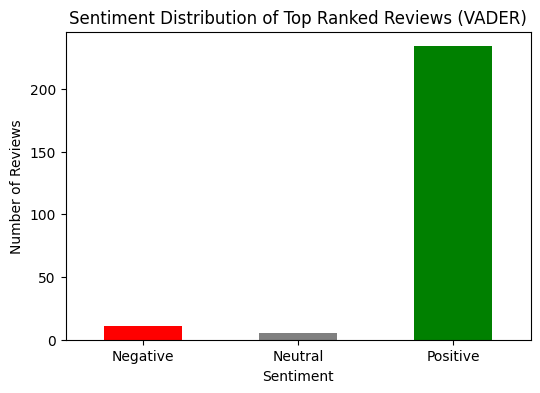

In [18]:
import matplotlib.pyplot as plt

color_map = {
    "Positive": "green",
    "Neutral": "gray",
    "Negative": "red"
}

colors = [color_map[s] for s in sentiment_counts.index]

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind="bar", color=colors)

plt.title("Sentiment Distribution of Top Ranked Reviews (VADER)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)
plt.show()

In [19]:
from collections import Counter
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# combine top review text
text = " ".join(top_reviews["reviewText"].fillna("").astype(str)).lower()

# extract words
words = re.findall(r"\b[a-z]{3,}\b", text)

# remove stopwords
words = [w for w in words if w not in ENGLISH_STOP_WORDS]

# count keywords
keywords = Counter(words).most_common(10)

keywords

[('nook', 295),
 ('use', 259),
 ('like', 209),
 ('camera', 197),
 ('just', 190),
 ('good', 185),
 ('great', 162),
 ('palm', 149),
 ('don', 137),
 ('sound', 136)]

In [20]:
summary = {
    "Top Review Score": round(top_reviews["aco_score"].max(), 4),
    "Average ACO Score": round(df_sorted["aco_score"].mean(), 4),
    "Most Important Feature": importance.iloc[0]["feature"] if not importance.empty else None,
    "Positive Reviews": int(sentiment_counts.get("Positive", 0)),
    "Neutral Reviews": int(sentiment_counts.get("Neutral", 0)),
    "Negative Reviews": int(sentiment_counts.get("Negative", 0))
}

summary

{'Top Review Score': np.float64(1.0),
 'Average ACO Score': np.float64(0.319),
 'Most Important Feature': 'helpfulness_ratio',
 'Positive Reviews': 234,
 'Neutral Reviews': 5,
 'Negative Reviews': 11}

In [21]:
report = {
    "top_reviews": top_reviews[["aco_score","reviewText"]],
    "feature_importance": importance,
    "sentiment_distribution": sentiment_counts
}

top_reviews.to_csv("../results/top_aco_reviews.csv", index=False)
importance.to_csv("../results/aco_feature_importance.csv", index=False)

print("Structured report files saved in results folder.")

Structured report files saved in results folder.


In [22]:
baseline_corr = np.corrcoef(df["baseline_score"], ground_truth)[0,1]
aco_corr = np.corrcoef(df["aco_score"], ground_truth)[0,1]

print("Baseline:", baseline_corr)
print("ACO:", aco_corr)

Baseline: 0.29523443337017724
ACO: 0.3771513778689363


In [23]:
def precision_at_k(scores, truth, k=100):

    top_pred = np.argsort(scores)[-k:]
    top_truth = np.argsort(truth)[-k:]

    return len(set(top_pred).intersection(set(top_truth))) / k

baseline_p = precision_at_k(df["baseline_score"], ground_truth)
aco_p = precision_at_k(df["aco_score"], ground_truth)

print("Baseline:", baseline_p)
print("ACO:", aco_p)

Baseline: 0.12
ACO: 0.5


In [24]:
from sklearn.metrics import ndcg_score

true = ground_truth.reshape(1, -1)

baseline_ndcg = ndcg_score(true, df["baseline_score"].values.reshape(1,-1))
aco_ndcg = ndcg_score(true, df["aco_score"].values.reshape(1,-1))

print("Baseline:", baseline_ndcg)
print("ACO:", aco_ndcg)

Baseline: 0.6171485766403764
ACO: 0.8089174205418723


In [25]:
comparison = pd.DataFrame({
    "Metric": ["Correlation", "Precision@K", "NDCG"],
    "Baseline": [baseline_corr, baseline_p, baseline_ndcg],
    "ACO": [aco_corr, aco_p, aco_ndcg]
})

comparison

,Metric,Baseline,ACO
0,Correlation,0.295234,0.377151
1,Precision@K,0.120000,0.500000
2,NDCG,0.617149,0.808917


In [26]:
# Detailed accuracy metrics table

metrics_df = pd.DataFrame({
    "Metric": ["Correlation", "Precision@K", "NDCG"],
    "Baseline Score": [baseline_corr, baseline_p, baseline_ndcg],
    "ACO Score": [aco_corr, aco_p, aco_ndcg],
    "Improvement": [
        aco_corr - baseline_corr,
        aco_p - baseline_p,
        aco_ndcg - baseline_ndcg
    ]
})

metrics_df

,Metric,Baseline Score,ACO Score,Improvement
0,Correlation,0.295234,0.377151,0.081917
1,Precision@K,0.120000,0.500000,0.380000
2,NDCG,0.617149,0.808917,0.191769


In [27]:
# ===============================
# OVERALL ACCURACY CALCULATION
# ===============================

baseline_overall = (baseline_corr + baseline_p + baseline_ndcg) / 3
aco_overall = (aco_corr + aco_p + aco_ndcg) / 3

# convert to percentage
baseline_accuracy = baseline_overall * 100
aco_accuracy = aco_overall * 100

print(" Baseline Overall Accuracy: {:.2f}%".format(baseline_accuracy))
print(" ACO Overall Accuracy: {:.2f}%".format(aco_accuracy))

# improvement
improvement = aco_accuracy - baseline_accuracy

print("Improvement: {:.2f}%".format(improvement))

 Baseline Overall Accuracy: 34.41%
 ACO Overall Accuracy: 56.20%
Improvement: 21.79%


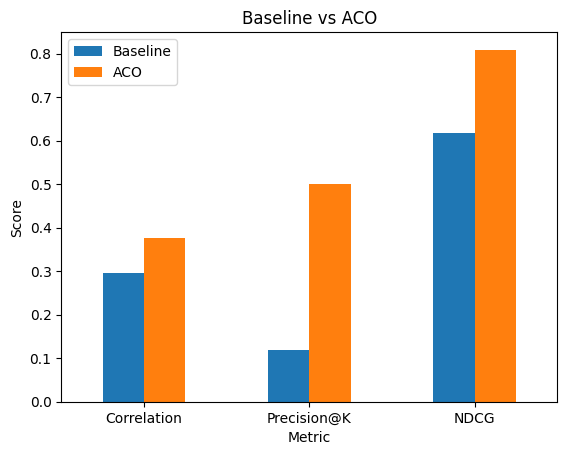

In [28]:
import matplotlib.pyplot as plt

# create plot
comparison.set_index("Metric").plot(kind="bar")

plt.title("Baseline vs ACO")
plt.ylabel("Score")
plt.xticks(rotation=0)

# save image
graph_path = "../results/comparison_plot.png"
plt.savefig(graph_path, bbox_inches='tight')

plt.show()

In [29]:
comparison.to_csv("../results/model_comparison.csv", index=False)

print("FINAL REPORT SAVED")

FINAL REPORT SAVED


In [31]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from openpyxl.drawing.image import Image

# ===============================
# CREATE GRAPH
# ===============================

graph_path = "../results/comparison_plot.png"

comparison.set_index("Metric").plot(kind="bar")

plt.title("Baseline vs ACO")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.savefig(graph_path, bbox_inches='tight')
plt.close()

# ===============================
# SETUP FILE
# ===============================

os.makedirs("../results", exist_ok=True)

report_path = "../results/aco_full_report.xlsx"

# delete old file (fix permission issues)
if os.path.exists(report_path):
    try:
        os.remove(report_path)
    except PermissionError:
        print(" Close Excel file and rerun.")
        raise

# ===============================
# PREPARE DATA
# ===============================

# summary
summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])

# sentiment
sentiment_df = sentiment_counts.reset_index()
sentiment_df.columns = ["Sentiment", "Count"]

# keywords
keywords_df = pd.DataFrame(keywords, columns=["Keyword", "Frequency"])

# ===============================
# METRICS + OVERALL ACCURACY
# ===============================

metrics_df = pd.DataFrame({
    "Metric": ["Correlation", "Precision@K", "NDCG"],
    "Baseline Score": [baseline_corr, baseline_p, baseline_ndcg],
    "ACO Score": [aco_corr, aco_p, aco_ndcg]
})

# improvement
metrics_df["Improvement"] = metrics_df["ACO Score"] - metrics_df["Baseline Score"]

# improvement %
metrics_df["Improvement (%)"] = (
    metrics_df["Improvement"] / metrics_df["Baseline Score"]
) * 100

#  ADD OVERALL ACCURACY ROW
baseline_overall = metrics_df["Baseline Score"].mean()
aco_overall = metrics_df["ACO Score"].mean()

overall_row = pd.DataFrame({
    "Metric": ["Overall Accuracy"],
    "Baseline Score": [baseline_overall],
    "ACO Score": [aco_overall],
    "Improvement": [aco_overall - baseline_overall],
    "Improvement (%)  ": [     #(aco_overall - baseline_overall) / baseline_overall
        ((aco_overall - baseline_overall) / baseline_overall) * 100
    ]
})

metrics_df = pd.concat([metrics_df, overall_row], ignore_index=True)

# ===============================
# WRITE EXCEL
# ===============================

with pd.ExcelWriter(report_path, engine="openpyxl") as writer:

    top_reviews[["aco_score","reviewText"]].to_excel(writer, sheet_name="Top Reviews", index=False)
    importance.to_excel(writer, sheet_name="Feature Importance", index=False)
    sentiment_df.to_excel(writer, sheet_name="Sentiment Distribution", index=False)
    summary_df.to_excel(writer, sheet_name="Summary Metrics", index=False)
    keywords_df.to_excel(writer, sheet_name="Top Keywords", index=False)
    comparison.to_excel(writer, sheet_name="Model Comparison", index=False)
    metrics_df.to_excel(writer, sheet_name="Accuracy Details", index=False)

# ===============================
# INSERT GRAPH INTO EXCEL
# ===============================

wb = load_workbook(report_path)

ws = wb.create_sheet("Comparison Graph")

img = Image(graph_path)
ws.add_image(img, "A1")

wb.save(report_path)

print("Full report + graph + overall accuracy saved successfully:", report_path)

Full report + graph + overall accuracy saved successfully: ../results/aco_full_report.xlsx
